# Customer Churn Analytics

## Data Understanding

# Business Problem

TeleConnect Australia has observed that a significant number of customers are cancelling their services. Customer churn reduces revenue and increases the cost of acquiring new customers. The company wants to understand why customers leave and develop a predictive model to identify customers who are at risk of churning.

# Project Objective

The objective of this project is to:

- Understand customer behaviour.
- Identify factors influencing customer churn.
- Build a machine learning model to predict churn.
- Provide business recommendations to improve customer retention.
- Develop a Power BI dashboard for business users.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Dictionary

| Column | Description | Type |
|---------|-------------|------|
| customerID | Unique customer identifier | Identifier |
| gender | Customer gender | Categorical |
| SeniorCitizen | Whether customer is a senior citizen (0 = No, 1 = Yes) | Binary |
| Partner | Whether the customer has a partner | Binary |
| Dependents | Whether the customer has dependents | Binary |
| tenure | Number of months the customer has stayed | Numerical |
| PhoneService | Whether phone service is active | Binary |
| MultipleLines | Whether customer has multiple phone lines | Categorical |
| InternetService | Internet service type | Categorical |
| OnlineSecurity | Online security subscription | Categorical |
| OnlineBackup | Online backup subscription | Categorical |
| DeviceProtection | Device protection plan | Categorical |
| TechSupport | Technical support subscription | Categorical |
| StreamingTV | TV streaming service | Categorical |
| StreamingMovies | Movie streaming service | Categorical |
| Contract | Contract type | Categorical |
| PaperlessBilling | Paperless billing status | Binary |
| PaymentMethod | Payment method | Categorical |
| MonthlyCharges | Monthly service charges | Numerical |
| TotalCharges | Total amount charged | Numerical (needs cleaning) |
| Churn | Target variable (Yes/No) | Binary |

In [2]:
df.shape

(7043, 21)

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [7]:
type(df["TotalCharges"][0])

str

In [9]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [10]:
type(df["TotalCharges"][0])

str

In [11]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Matplotlib is building the font cache; this may take a moment.


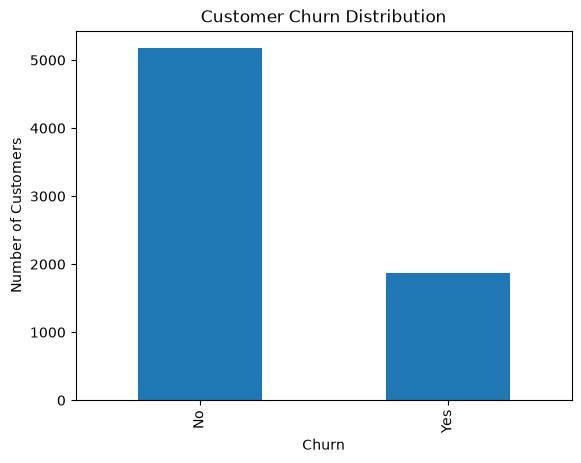

In [13]:
import matplotlib.pyplot as plt

# Count customers by churn status
df["Churn"].value_counts().plot(kind="bar")

# Add title and labels
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

### Insight 1

- Total customers: 7,043
- Customers who churned: 1,869 (26.54%)
- Customers retained: 5,174 (73.46%)


In [14]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [15]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
).round(2) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.0,43.0
One year,89.0,11.0
Two year,97.0,3.0


## Insight 2 – Contract Type vs Churn

### Observation

- Month-to-month customers have a churn rate of **43%**.
- One-year contract customers have a churn rate of **11%**.
- Two-year contract customers have a churn rate of **3%**.

Business Interpretation

Customers with longer-term contracts are much less likely to leave the company. Offering incentives for customers to switch from month-to-month plans to annual contracts could reduce churn and improve customer retention.

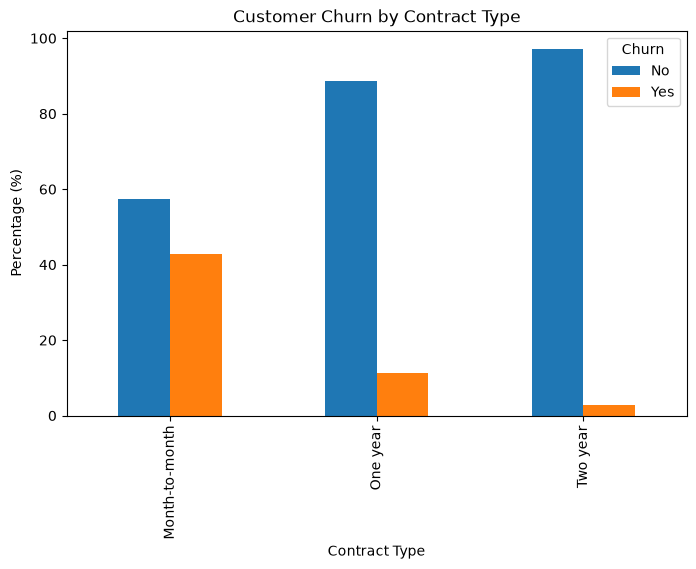

In [16]:
import matplotlib.pyplot as plt

# Create percentage table
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

# Plot
contract_churn.plot(kind="bar", figsize=(8,5))

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")
plt.show()

In [17]:
# Create a copy of the original dataset
df_clean = df.copy()

df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
(df_clean["TotalCharges"] == " ").sum()

np.int64(11)

In [20]:
import numpy as np

df_clean["TotalCharges"] = df_clean["TotalCharges"].replace(" ", np.nan)

In [21]:
df_clean.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [ ]:
# Data Cleaning

## Cleaning Task 1 – Missing Values

### Problem

The `TotalCharges` column was stored as text because some rows contained blank strings instead of numeric values.

### Solution

Blank strings were converted to `NaN` so that Pandas can correctly identify and process missing values.

### Result

11 missing values were identified in the `TotalCharges` column.

In [22]:
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

In [23]:
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"])

In [24]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
## Cleaning Task 2 – Fixing `TotalCharges`

### Problem
The `TotalCharges` column was stored as text because blank strings prevented Pandas from recognising it as numeric.

### Solution
Blank values were replaced with `0` because the affected customers had a tenure of 0 months. The column was then converted to a numeric data type.

### Result
`TotalCharges` is now a numeric column (`float64`) and can be used in calculations and machine learning models.